In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv


In [4]:
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('/kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv')

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [14]:
df.shape

(569, 32)

In [5]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [9]:
# Removing the Unnecessary last Column

df=df.drop(columns=('Unnamed: 32'),axis=1)

In [10]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

<Axes: xlabel='diagnosis'>

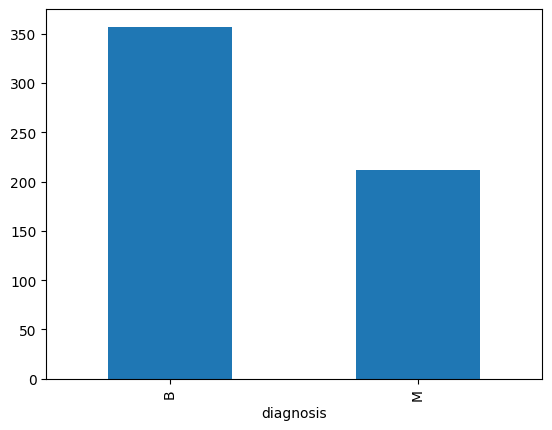

In [13]:
df['diagnosis'].value_counts().plot(kind='bar')

In [15]:
# Encoded the Target Column Using An LabelEncoder

In [17]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
df['diagnosis']=le.fit_transform(df['diagnosis'])

In [19]:
# Transformed Target Column
df['diagnosis']

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [20]:
df.head(2)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [25]:
x=df.iloc[:,2:]
y=df.iloc[:,1]

In [28]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2,random_state=42)

scaler=StandardScaler()

In [29]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [30]:
# LogisticRegression

lr=LogisticRegression()

lr.fit(x_train,y_train)

LogisticRegression()

In [33]:
y_pred=lr.predict(x_test)

print('Accuracy :',accuracy_score(y_test,y_pred))

Accuracy : 0.9736842105263158


# Now Try to Stay this Accuracy Using An PCA

In [34]:
from sklearn.decomposition import PCA

In [50]:
pca = PCA(n_components=10)

x_train_scaled = pca.fit_transform(x_train)
x_test_scaled = pca.transform(x_test)

In [51]:
model = LogisticRegression()
model . fit(x_train_scaled,y_train)

LogisticRegression()

In [52]:
pred = model.predict(x_test_scaled)
print("accuracy With PCA :",accuracy_score(y_test,pred))

accuracy With PCA : 0.9824561403508771


In [53]:
print(pca.n_components_)

10


In [42]:
np.cumsum(pca.explained_variance_ratio_)

array([0.43502782, 0.63002788, 0.72784307, 0.79270717, 0.84524094,
       0.88636894, 0.90872484, 0.92520437, 0.93900488, 0.95105751,
       0.96162316, 0.97045804, 0.97818188, 0.98349877, 0.98639913,
       0.98914777, 0.99116898, 0.9929821 , 0.99461913, 0.99565834,
       0.99665687, 0.9975357 , 0.99834552, 0.99892219, 0.99941849,
       0.99969478, 0.99992059, 0.99997136, 0.99999594, 1.        ])

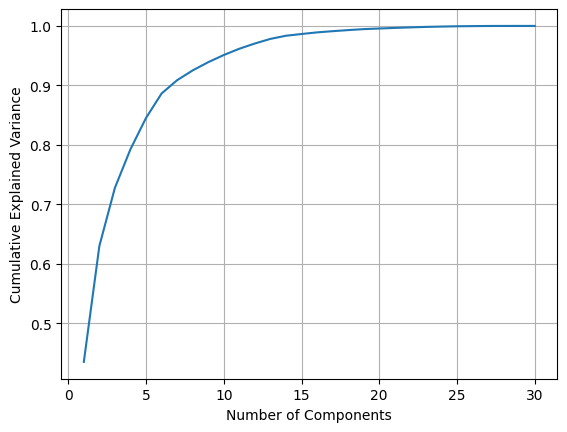

In [44]:
import numpy as np
import matplotlib.pyplot as plt

cumsum = np.cumsum(pca.explained_variance_ratio_)

plt.plot(range(1, len(cumsum)+1), cumsum)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()

## Visualization

In [54]:
pca=PCA(n_components=2)

x_train_tra = pca.fit_transform(x_train)
x_test_tra = pca.transform(x_test)

In [60]:
import plotly.express as px

y_train_tra = y_train.astype(str)

fig = px.scatter(
    x=x_train_tra[:,0],
    y=x_train_tra[:,1],
    color=y_train,
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.show()

In [58]:

pca = PCA(n_components=3)

x_train_tra = pca.fit_transform(x_train)

import plotly.express as px

y_train_tra = y_train.astype(str)

fig = px.scatter_3d(
    x=x_train_tra[:,0],
    y=x_train_tra[:,1],
    z=x_train_tra[:,2],
    color=y_train_tra,
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.show()